In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import optuna

RANDOM_STATE = 42
CLASS_ORDER = [0, 1, 2]
ORIGINAL_CLASS_NAMES = {0: "Home win", 1: "Draw", 2: "Away win"}
CLASS_LABELS = [ORIGINAL_CLASS_NAMES[i] for i in CLASS_ORDER]



### Base and Helper Functions

In [ ]:
def validate_original_labels(y, split_name):
    values = set(pd.Series(y).dropna().astype(int).unique())
    expected = {0, 1, 2}
    unexpected = values - expected
    if unexpected:
        raise ValueError(
            f"{split_name} contains unexpected winner_code values: {sorted(unexpected)}"
        )


def binary_model_inference(model, X):
    """Return P(target=1) and P(target=0), regardless of the internal class-column order."""
    classes = np.asarray(model.classes_, dtype=int)
    positive_columns = np.flatnonzero(classes == 1)
    negative_columns = np.flatnonzero(classes == 0)
    if len(positive_columns) != 1:
        raise ValueError(f"Expected binary classes including 1, found {classes.tolist()}")
    probabilities = model.predict_proba(X)
    return probabilities[:, positive_columns[0]], probabilities[: negative_columns[0]]


def binary_metrics(y_true, positive_probs, threshold=0.5):
    y_true = np.asarray(y_true, dtype=int)
    positive_probs = np.asarray(positive_probs, dtype=float)
    predicted = (positive_probs >= threshold).astype(int)

    return {
        "log_loss": log_loss(y_true, positive_probs, labels=[0, 1]),
        "brier_score": brier_score_loss(y_true, positive_probs),
        "roc_auc": roc_auc_score(y_true, positive_probs),
        "average_precision": average_precision_score(y_true, positive_probs),
        "accuracy_at_0.5": accuracy_score(y_true, predicted),
        "precision_at_0.5": precision_score(y_true, predicted, zero_division=0),
        "recall_at_0.5": recall_score(y_true, predicted, zero_division=0),
        "f1_at_0.5": f1_score(y_true, predicted, zero_division=0),
    }


def plot_binary_calibration(y_true, positive_probs, title, n_bins=10):
    prob_true, prob_pred = calibration_curve(
        y_true, positive_probs, n_bins=n_bins, strategy="quantile"
    )
    plt.figure(figsize=(7, 6))
    plt.plot(prob_pred, prob_true, marker="o", label=title)
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(f"Calibration: {title}")
    plt.grid(True)
    plt.legend()
    plt.show()


def calibration_table(y_true, positive_probs, n_bins=10):
    frame = pd.DataFrame({"actual": np.asarray(y_true), "probability": positive_probs})
    frame["bin"] = pd.qcut(
        frame["probability"], q=n_bins, duplicates="drop"
    )
    return (
        frame.groupby("bin", observed=True)
        .agg(
            count=("actual", "size"),
            mean_probability=("probability", "mean"),
            observed_rate=("actual", "mean"),
        )
        .reset_index()
    )


def make_combination_features(prob_home, prob_away):
    '''Create second-level features from the two binary base probabilities.'''
    prob_home = np.asarray(prob_home, dtype=float)
    prob_away = np.asarray(prob_away, dtype=float)

    eps = 1e-6
    clipped_home = np.clip(prob_home, eps, 1 - eps)
    clipped_away = np.clip(prob_away, eps, 1 - eps)

    return pd.DataFrame(
        {
            "prob_home": prob_home,
            "prob_away": prob_away,
            "prob_difference": prob_home - prob_away,
            "absolute_difference": np.abs(prob_home - prob_away),
            "prob_sum": prob_home + prob_away,
            # This is a diagnostic feature, not an assumed draw probability.
            "raw_draw_residual": 1.0 - prob_home - prob_away,
            "home_logit": np.log(clipped_home / (1.0 - clipped_home)),
            "away_logit": np.log(clipped_away / (1.0 - clipped_away)),
        }
    )


def align_multiclass_probabilities(raw_probabilities, model_classes, epsilon=1e-12):
    '''Align predict_proba columns to CLASS_ORDER and return normalized probabilities.'''
    raw_probabilities = np.asarray(raw_probabilities, dtype=float)
    model_classes = np.asarray(model_classes, dtype=int)

    aligned = np.full(
        (len(raw_probabilities), len(CLASS_ORDER)),
        epsilon,
        dtype=float,
    )

    for source_column, class_code in enumerate(model_classes):
        target_column = CLASS_ORDER.index(int(class_code))
        aligned[:, target_column] = raw_probabilities[:, source_column]

    aligned /= aligned.sum(axis=1, keepdims=True)
    return aligned


def multiclass_brier_score(y_true, probabilities):
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    actual_one_hot = np.eye(len(CLASS_ORDER))[y_true]
    return float(np.mean(np.sum((probabilities - actual_one_hot) ** 2, axis=1)))


def multiclass_probability_metrics(y_true, probabilities):
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predicted = np.asarray(CLASS_ORDER)[probabilities.argmax(axis=1)]

    return {
        "log_loss": log_loss(y_true, probabilities, labels=CLASS_ORDER),
        "multiclass_brier": multiclass_brier_score(y_true, probabilities),
        "accuracy": accuracy_score(y_true, predicted),
        "balanced_accuracy": balanced_accuracy_score(y_true, predicted),
        "macro_precision": precision_score(
            y_true, predicted, labels=CLASS_ORDER, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, predicted, labels=CLASS_ORDER, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, predicted, labels=CLASS_ORDER, average="macro", zero_division=0
        ),
    }


def label_metrics(y_true_labels, predicted_labels):
    return {
        "accuracy": accuracy_score(y_true_labels, predicted_labels),
        "balanced_accuracy": balanced_accuracy_score(y_true_labels, predicted_labels),
        "macro_precision": precision_score(
            y_true_labels,
            predicted_labels,
            labels=CLASS_LABELS,
            average="macro",
            zero_division=0,
        ),
        "macro_recall": recall_score(
            y_true_labels,
            predicted_labels,
            labels=CLASS_LABELS,
            average="macro",
            zero_division=0,
        ),
        "macro_f1": f1_score(
            y_true_labels,
            predicted_labels,
            labels=CLASS_LABELS,
            average="macro",
            zero_division=0,
        ),
    }


def make_combination_model(C=1.0, class_weight=None):
    """Return the multinomial model that reconciles the binary predictions."""
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=C,
            solver="lbfgs",
            max_iter=5000,
            random_state=RANDOM_STATE,
            class_weight=class_weight
        ),
    )


def aligned_three_way_probabilities(model, X_meta, class_order=(0, 1, 2)):
    """Return predict_proba columns in the requested 0/1/2 class order."""
    raw_probabilities = model.predict_proba(X_meta)
    learned_classes = np.asarray(model.classes_, dtype=int)

    aligned = np.zeros((len(X_meta), len(class_order)), dtype=float)
    class_to_column = {
        class_label: column
        for column, class_label in enumerate(class_order)
    }

    for model_column, class_label in enumerate(learned_classes):
        if int(class_label) in class_to_column:
            aligned[:, class_to_column[int(class_label)]] = raw_probabilities[:, model_column]

    row_sums = aligned.sum(axis=1, keepdims=True)
    if np.any(row_sums <= 0):
        raise ValueError("The combination model returned an invalid probability row.")

    aligned = aligned / row_sums
    return aligned


def observation_ranked_probability_score(
    y_true,
    predicted_probabilities,
    class_order=(0, 1, 2),
    normalize=True,
):
    """
    Return one Ranked Probability Score per observation.

    The class order is Home win (0), Draw (1), Away win (2).
    Lower is better. With normalize=True, the score lies between 0 and 1.
    """
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(predicted_probabilities, dtype=float)
    n_classes = len(class_order)

    if probabilities.ndim != 2 or probabilities.shape[1] != n_classes:
        raise ValueError(
            f"Expected probability shape (n, {n_classes}); received {probabilities.shape}."
        )

    if np.any(probabilities < -1e-12) or np.any(probabilities > 1.0 + 1e-12):
        raise ValueError("Predicted probabilities must lie between 0 and 1.")

    if not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-6):
        raise ValueError("Each probability row must sum to 1 before calculating RPS.")

    class_to_position = {
        class_label: position
        for position, class_label in enumerate(class_order)
    }

    try:
        actual_positions = np.array(
            [class_to_position[int(value)] for value in y_true],
            dtype=int,
        )
    except KeyError as exc:
        raise ValueError(f"Unexpected class label in y_true: {exc.args[0]}") from exc

    actual_one_hot = np.eye(n_classes)[actual_positions]
    predicted_cumulative = np.cumsum(probabilities, axis=1)[:, :-1]
    actual_cumulative = np.cumsum(actual_one_hot, axis=1)[:, :-1]

    scores = np.sum(
        (predicted_cumulative - actual_cumulative) ** 2,
        axis=1,
    )

    if normalize:
        scores = scores / (n_classes - 1)

    return scores


def ranked_probability_score(
    y_true,
    predicted_probabilities,
    class_order=(0, 1, 2),
    normalize=True,
):
    """Return mean RPS. Lower values indicate better probability forecasts."""
    return float(
        observation_ranked_probability_score(
            y_true=y_true,
            predicted_probabilities=predicted_probabilities,
            class_order=class_order,
            normalize=normalize,
        ).mean()
    )


### Data Preprocessing 

In [20]:
features = pd.read_csv("stored_features/match_features_c_25_mu1_0.20_mu2_0.10.csv")

features["date"] = pd.to_datetime(features["date"], errors="raise")
features = (
    features.loc[
        (features["date"] < pd.Timestamp("2026-06-01"))
        & (features["date"] > pd.Timestamp("1970-01-01"))
    ]
    .sort_values(by="date", ascending=True, kind="stable")
    .reset_index(drop=True)
)

assert features["date"].is_monotonic_increasing
validate_original_labels(features["winner_code"], "Full dataset")
print(features["winner_code"].value_counts(dropna=False).sort_index())


winner_code
0    14174
1     9237
2    15118
Name: count, dtype: int64


In [21]:
features = features.drop(
    columns=[
        "match_id",
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "winner",
        #"home_avg_goal_difference_last_10",
        #"away_avg_goal_difference_last_10",
        "home_failed_score_rate_last_5",
        "away_failed_score_rate_last_5",
        #"home_days_since_last_game",
        #"away_days_since_last_game",
        "diff_under_1_5_rate",
        "home_over_2_5_rate_last_5",
        "away_over_2_5_rate_last_5",
        "home_over_3_5_rate_last_5",
        "away_over_3_5_rate_last_5",
        "diff_over_2_5_rate",
        "home_under_1_5_rate_last_5",
        "away_under_1_5_rate_last_5",
        #"home_pi_expected_gd",
        #"away_pi_expected_gd",
    ]
)


In [22]:
# Build two independent binary targets from the agreed original coding.
original_y = features["winner_code"].astype(int)
X = features.drop(columns=["winner_code"])

y_home_win = (original_y == 0).astype(int)  # 1 = home win; 0 = draw or away win
y_away_win = (original_y == 2).astype(int)  # 1 = away win; 0 = draw or home win

if len(features) < 20:
    raise ValueError("The dataset is too small for a chronological train/test split.")

n_rows = len(features)

train_end = int(n_rows * 0.65)
calibration_end = int(n_rows * 0.80)

X_train_raw = X.iloc[:train_end].copy()
original_y_train = original_y.iloc[:train_end].copy()
y_home_train = y_home_win.iloc[:train_end].copy()
y_away_train = y_away_win.iloc[:train_end].copy()

X_calibration_raw = X.iloc[train_end:calibration_end].copy()
original_y_calibration = original_y.iloc[train_end:calibration_end].copy()
y_home_calibration = y_home_win.iloc[train_end:calibration_end].copy()
y_away_calibration = y_away_win.iloc[train_end:calibration_end].copy()

X_test_raw = X.iloc[calibration_end:].copy()
original_y_test = original_y.iloc[calibration_end:].copy()
y_home_test = y_home_win.iloc[calibration_end:].copy()
y_away_test = y_away_win.iloc[calibration_end:].copy()

validate_original_labels(original_y_train, "Training set")
validate_original_labels(
    original_y_calibration,
    "Calibration set",
)
validate_original_labels(original_y_test, "Test set")

for split_name, target in [
    ("Training", original_y_train),
    ("Calibration", original_y_calibration),
    ("Test", original_y_test),
]:
    print(f"\n{split_name} rows: {len(target):,}")
    display(
        target
        .map(ORIGINAL_CLASS_NAMES)
        .value_counts()
        .rename("count")
    )

assert len(X_train_raw) > 0
assert len(X_calibration_raw) > 0
assert len(X_test_raw) > 0

assert X_train_raw.index.max() < X_calibration_raw.index.min()
assert X_calibration_raw.index.max() < X_test_raw.index.min()



Training rows: 25,043


winner_code
Away win    9807
Home win    9167
Draw        6069
Name: count, dtype: int64


Calibration rows: 5,780


winner_code
Away win    2305
Home win    2128
Draw        1347
Name: count, dtype: int64


Test rows: 7,706


winner_code
Away win    3006
Home win    2879
Draw        1821
Name: count, dtype: int64

# Optuna hyperparameter tuning

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
from sklearn.utils.class_weight import compute_sample_weight

def make_objective(X_raw, y, model_name):
    def objective(trial):
        params = {
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "random_state": RANDOM_STATE,
            "n_estimators": trial.suggest_int("n_estimators", 200, 1000, step=20),
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 6),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0, step=0.1),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0, step=0.05),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.6, 1.0, step=0.05
            ),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 50.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10.0, log=True),
            "tree_method": "hist",
            "n_jobs": -1,
        }

        fold_brier = []
        fold_logloss = []
        fold_auc = []

        for fold_number, (train_idx, val_idx) in enumerate(tscv.split(X_raw), start=1):
            fold_X_train_raw = X_raw.iloc[train_idx]
            fold_X_val_raw = X_raw.iloc[val_idx]
            fold_y_train = y.iloc[train_idx]
            fold_y_val = y.iloc[val_idx]

            if fold_y_train.nunique() < 2 or fold_y_val.nunique() < 2:
                raise optuna.TrialPruned(
                    f"{model_name}, fold {fold_number}: only one target class present."
                )

            # imputer = SimpleImputer(strategy="median")
            # fold_X_train = imputer.fit_transform(fold_X_train_raw)
            # fold_X_val = imputer.transform(fold_X_val_raw)

            use_balanced_weights = compute_sample_weight(y=fold_y_train,class_weight="balanced")

            model = xgb.XGBClassifier(**params)
            model.fit(
                fold_X_train_raw,
                fold_y_train,
                #eval_set=[(fold_X_val_raw, fold_y_val)],
                verbose=False,
                sample_weight=use_balanced_weights
            )

            probabilities,_ = binary_model_inference(model, fold_X_val_raw)
            fold_brier.append(brier_score_loss(fold_y_val, probabilities))
            fold_logloss.append(log_loss(fold_y_val, probabilities, labels=[0, 1]))
            fold_auc.append(roc_auc_score(fold_y_val, probabilities))

            running_score = float(np.mean(fold_brier))
            trial.report(running_score, step=fold_number)
            if trial.should_prune():
                raise optuna.TrialPruned()

        mean_brier = float(np.mean(fold_brier))
        trial.set_user_attr("mean_log_loss", float(np.mean(fold_logloss)))
        trial.set_user_attr("mean_roc_auc", float(np.mean(fold_auc)))
        trial.set_user_attr("brier_std", float(np.std(fold_brier)))
        return mean_brier

    return objective

def separate_study_parameters(best_params):
    model_params = dict(best_params)

    use_balanced_weights = model_params.pop(
        "balanced_weights",
        False,
    )

    return model_params, use_balanced_weights


In [24]:
home_study = optuna.create_study(
    study_name="home_win_vs_not_home_win",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
)


home_study.optimize(
    make_objective(X_train_raw, y_home_train, "home-win model"),
    n_trials=50,
    show_progress_bar=True,
)

home_model_params, use_home_weights = (
    separate_study_parameters(home_study.best_params)
)

print("Best home-win parameters:", home_study.best_params)
print("Best home-win CV Brier score:", home_study.best_value)


[I 2026-07-15 09:01:29,997] A new study created in memory with name: home_win_vs_not_home_win


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-15 09:01:35,589] Trial 0 finished with value: 0.20168303549289704 and parameters: {'n_estimators': 500, 'learning_rate': 0.1358198535217987, 'max_depth': 5, 'min_child_weight': 12, 'gamma': 0.7000000000000001, 'subsample': 0.65, 'colsample_bytree': 0.6, 'reg_lambda': 21.76624112345367, 'reg_alpha': 0.040428727350273294}. Best is trial 0 with value: 0.20168303549289704.
[I 2026-07-15 09:01:51,210] Trial 1 finished with value: 0.19414704740047456 and parameters: {'n_estimators': 780, 'learning_rate': 0.020846957895078073, 'max_depth': 6, 'min_child_weight': 17, 'gamma': 1.0, 'subsample': 0.65, 'colsample_bytree': 0.65, 'reg_lambda': 0.6624310605949987, 'reg_alpha': 0.014077923139972392}. Best is trial 1 with value: 0.19414704740047456.
[I 2026-07-15 09:01:56,115] Trial 2 finished with value: 0.19417763650417327 and parameters: {'n_estimators': 540, 'learning_rate': 0.03596444270828742, 'max_depth': 5, 'min_child_weight': 3, 'gamma': 1.4000000000000001, 'subsample': 0.75, 'cols

In [25]:
away_study = optuna.create_study(
    study_name="away_win_vs_not_away_win",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + 1),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
)



away_study.optimize(
    make_objective(X_train_raw, y_away_train, "away-win model"),
    n_trials=50,
    show_progress_bar=True,
)

away_model_params, use_away_weights = (
    separate_study_parameters(away_study.best_params)
)

print("Best away-win parameters:", away_study.best_params)
print("Best away-win CV Brier score:", away_study.best_value)


[I 2026-07-15 09:03:31,583] A new study created in memory with name: away_win_vs_not_away_win


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-15 09:03:32,864] Trial 0 finished with value: 0.19532528817653655 and parameters: {'n_estimators': 280, 'learning_rate': 0.0682339528443407, 'max_depth': 2, 'min_child_weight': 5, 'gamma': 1.6, 'subsample': 0.95, 'colsample_bytree': 0.85, 'reg_lambda': 2.887889544752868, 'reg_alpha': 1.4930795478222954e-05}. Best is trial 0 with value: 0.19532528817653655.
[I 2026-07-15 09:03:39,521] Trial 1 finished with value: 0.20028317868709564 and parameters: {'n_estimators': 800, 'learning_rate': 0.04432364397243556, 'max_depth': 6, 'min_child_weight': 6, 'gamma': 0.2, 'subsample': 0.95, 'colsample_bytree': 0.65, 'reg_lambda': 1.2389516898154314, 'reg_alpha': 0.0007880954608106449}. Best is trial 0 with value: 0.19532528817653655.
[I 2026-07-15 09:03:40,622] Trial 2 finished with value: 0.19501437842845917 and parameters: {'n_estimators': 260, 'learning_rate': 0.10937127171867443, 'max_depth': 6, 'min_child_weight': 20, 'gamma': 1.9000000000000001, 'subsample': 1.0, 'colsample_bytree':

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
oof_parts = []

va_home_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_jobs=-1,
    **home_study.best_params,
)

va_away_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_jobs=-1,
    **away_study.best_params,
)

for fold_number, (train_idx, val_idx) in enumerate(
    tscv.split(X_train_raw),
    start=1,
):
    fold_X_train_raw = X_train_raw.iloc[train_idx]
    fold_X_val_raw = X_train_raw.iloc[val_idx]

    fold_y_home_train = y_home_train.iloc[train_idx]
    fold_y_away_train = y_away_train.iloc[train_idx]

    # Correct target: 0=Home, 1=Draw, 2=Away.
    fold_actual_result = original_y_train.iloc[val_idx]

    # imputer = SimpleImputer(strategy="median")
    # fold_X_train = imputer.fit_transform(fold_X_train_raw)
    # fold_X_val = imputer.transform(fold_X_val_raw)

    fold_home_model = clone(va_home_model)
    fold_away_model = clone(va_away_model)

    fold_home_weights = compute_sample_weight(
        class_weight="balanced",
        y=fold_y_home_train,
    )

    fold_away_weights = compute_sample_weight(
        class_weight="balanced",
        y=fold_y_away_train,
    )

    fold_home_model.fit(fold_X_train_raw, fold_y_home_train, verbose=False)
    fold_away_model.fit(fold_X_train_raw, fold_y_away_train, verbose=False)

    fold_prob_home,_ = binary_model_inference(fold_home_model, fold_X_val_raw)
    fold_prob_away,_ = binary_model_inference(fold_away_model, fold_X_val_raw)

    fold_output = pd.DataFrame(
        {
            "fold": fold_number,
            "actual_code": fold_actual_result.to_numpy(),
            "actual_result": fold_actual_result.map(ORIGINAL_CLASS_NAMES).to_numpy(),
            "prob_home_win": fold_prob_home,
            "prob_away_win": fold_prob_away,
        },
        index=fold_X_val_raw.index,
    )
    oof_parts.append(fold_output)

oof_prediction_output = pd.concat(oof_parts).sort_index()

print("OOF validation rows:", len(oof_prediction_output))
print("OOF actual class counts:")
display(oof_prediction_output["actual_result"].value_counts())

assert set(oof_prediction_output["actual_code"].unique()) == set(CLASS_ORDER)
assert (oof_prediction_output["actual_result"] == "Away win").any()
display(oof_prediction_output.head())


OOF validation rows: 20865
OOF actual class counts:


actual_result
Away win    8189
Home win    7547
Draw        5129
Name: count, dtype: int64

,fold,actual_code,actual_result,prob_home_win,prob_away_win
4178,1,0,Home win,0.656265,0.157261
4179,1,0,Home win,0.344195,0.417816
4180,1,0,Home win,0.584761,0.119580
4181,1,0,Home win,0.710991,0.067825
4182,1,0,Home win,0.266111,0.341890


In [27]:
X_combination_oof = make_combination_features(
    oof_prediction_output["prob_home_win"],
    oof_prediction_output["prob_away_win"],
)
y_combination_oof = oof_prediction_output["actual_code"].astype(int).reset_index(drop=True)
X_combination_oof = X_combination_oof.reset_index(drop=True)

# Select the stacker's regularization using chronological validation RPS.
combination_cv = TimeSeriesSplit(n_splits=4)
combination_C_values = np.logspace(-3, 3, 13)
combination_tuning_rows = []

combination_class_weights = [
    None,
    "balanced",
]
for C in combination_C_values:
    for class_weight in combination_class_weights:
        fold_scores = []

        for train_idx, val_idx in combination_cv.split(X_combination_oof):
            X_meta_train = X_combination_oof.iloc[train_idx]
            X_meta_val = X_combination_oof.iloc[val_idx]
            y_meta_train = y_combination_oof.iloc[train_idx]
            y_meta_val = y_combination_oof.iloc[val_idx]

            if y_meta_train.nunique() < 2:
                continue

            candidate_model = make_combination_model(C=C, class_weight=class_weight)
            candidate_model.fit(X_meta_train, y_meta_train)

            candidate_probabilities = aligned_three_way_probabilities(
                candidate_model,
                X_meta_val,
                class_order=(0, 1, 2),
            )

            fold_scores.append(
                ranked_probability_score(
                    y_meta_val,
                    candidate_probabilities,
                    class_order=(0, 1, 2),
                )
            )

        if not fold_scores:
            continue

        combination_tuning_rows.append(
            {
                "C": C,
                "class_weight": (
                    "None"
                    if class_weight is None
                    else class_weight
                ),
                "mean_validation_rps": float(
                    np.mean(fold_scores)
                ),
                "std_validation_rps": float(
                    np.std(fold_scores)
                ),
            }
        )

combination_tuning_results = (
    pd.DataFrame(combination_tuning_rows)
    .sort_values(["mean_validation_rps", "std_validation_rps"])
    .reset_index(drop=True)
)

if combination_tuning_results.empty:
    raise ValueError("Unable to tune the three-way combination model.")

best_combination_C = float(combination_tuning_results.loc[0, "C"])

print(f"Best combination-model C: {best_combination_C:g}")
print(
    "Best chronological validation RPS:",
    f"{combination_tuning_results.loc[0, 'mean_validation_rps']:.6f}",
)
display(combination_tuning_results)

combination_model = make_combination_model(C=best_combination_C)
combination_model.fit(X_combination_oof, y_combination_oof)


Best combination-model C: 0.1
Best chronological validation RPS: 0.182279


,C,class_weight,mean_validation_rps,std_validation_rps
0,0.100000,None,0.182279,0.002638
1,0.316228,None,0.182285,0.002622
2,1.000000,None,0.182295,0.002612
3,3.162278,None,0.182300,0.002607
4,10.000000,None,0.182302,0.002605
5,31.622777,None,0.182303,0.002604
6,100.000000,None,0.182303,0.002604
7,316.227766,None,0.182303,0.002604
8,1000.000000,None,0.182303,0.002604
9,0.031623,None,0.182303,0.002651


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['prob_home','prob_away','prob_difference',...,'raw_draw_residual', 'home_logit','away_logit']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [28]:
gammas = np.arange(0.35, 0.65, 0.005)  # home threshold
betas = np.arange(0.35, 0.65, 0.005)   # away threshold

actual = oof_prediction_output["actual_result"].to_numpy()
home_probs = oof_prediction_output["prob_home_win"].to_numpy()
away_probs = oof_prediction_output["prob_away_win"].to_numpy()

threshold_rows = []

for gamma in gammas:
    for beta in betas:
        home_pass = home_probs >= gamma
        away_pass = away_probs >= beta

        pred = np.full(len(oof_prediction_output), "Draw", dtype=object)
        pred[home_pass & ~away_pass] = "Home win"
        pred[away_pass & ~home_pass] = "Away win"

        both_pass = home_pass & away_pass
        home_relative_confidence = home_probs / gamma
        away_relative_confidence = away_probs / beta

        pred[both_pass & (home_relative_confidence >= away_relative_confidence)] = "Home win"
        pred[both_pass & (away_relative_confidence > home_relative_confidence)] = "Away win"

        class_precision = precision_score(
            actual, pred, labels=CLASS_LABELS, average=None, zero_division=0
        )
        class_recall = recall_score(
            actual, pred, labels=CLASS_LABELS, average=None, zero_division=0
        )

        threshold_rows.append(
            {
                "gamma_home": gamma,
                "beta_away": beta,
                "accuracy": accuracy_score(actual, pred),
                "balanced_accuracy": balanced_accuracy_score(actual, pred),
                "macro_precision": precision_score(
                    actual, pred, labels=CLASS_LABELS, average="macro", zero_division=0
                ),
                "macro_recall": recall_score(
                    actual, pred, labels=CLASS_LABELS, average="macro", zero_division=0
                ),
                "macro_f1": f1_score(
                    actual, pred, labels=CLASS_LABELS, average="macro", zero_division=0
                ),
                "home_precision": class_precision[0],
                "draw_precision": class_precision[1],
                "away_precision": class_precision[2],
                "home_recall": class_recall[0],
                "draw_recall": class_recall[1],
                "away_recall": class_recall[2],
                "predicted_home_wins": int((pred == "Home win").sum()),
                "predicted_draws": int((pred == "Draw").sum()),
                "predicted_away_wins": int((pred == "Away win").sum()),
            }
        )

threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results.head())


,gamma_home,beta_away,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,home_precision,draw_precision,away_precision,home_recall,draw_recall,away_recall,predicted_home_wins,predicted_draws,predicted_away_wins
0,0.35,0.350,0.557824,0.499118,0.483401,0.499118,0.453630,0.553459,0.314421,0.582325,0.722936,0.051862,0.722555,9858,846,10161
1,0.35,0.355,0.557297,0.499221,0.483457,0.499221,0.455262,0.552100,0.313661,0.584611,0.724526,0.055956,0.717182,9904,915,10046
2,0.35,0.360,0.557057,0.500007,0.486173,0.500007,0.458663,0.551325,0.319961,0.587233,0.725189,0.063755,0.711076,9927,1022,9916
3,0.35,0.365,0.557201,0.500791,0.486592,0.500791,0.461060,0.550662,0.318264,0.590849,0.727309,0.068629,0.706435,9968,1106,9791
4,0.35,0.370,0.557105,0.501456,0.486958,0.501456,0.463561,0.550265,0.316445,0.594164,0.728899,0.074283,0.701185,9997,1204,9664


In [29]:
minimum_class_recall = 0.15

eligible_results = threshold_results.loc[
    (threshold_results["home_recall"] >= minimum_class_recall)
    & (threshold_results["draw_recall"] >= minimum_class_recall)
    & (threshold_results["away_recall"] >= minimum_class_recall)
].copy()

if eligible_results.empty:
    raise ValueError(
        "No threshold pair satisfies the minimum recall for every class. "
        "Lower minimum_class_recall or inspect the base-model calibration."
    )

eligible_results = eligible_results.sort_values(
    by=["macro_precision",
        "macro_f1",
        "accuracy",],
    ascending=False,
).reset_index(drop=True)

best_gamma = float(eligible_results.loc[0, "gamma_home"])
best_beta = float(eligible_results.loc[0, "beta_away"])

print(f"Best corrected home threshold: {best_gamma:.3f}")
print(f"Best corrected away threshold: {best_beta:.3f}")
display(eligible_results.head(20))


Best corrected home threshold: 0.650
Best corrected away threshold: 0.650


,gamma_home,beta_away,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,home_precision,draw_precision,away_precision,home_recall,draw_recall,away_recall,predicted_home_wins,predicted_draws,predicted_away_wins
0,0.650,0.650,0.416966,0.464565,0.611994,0.464565,0.415389,0.763449,0.281042,0.791491,0.265138,0.830961,0.297594,2621,15165,3079
1,0.645,0.650,0.419363,0.466544,0.611887,0.466544,0.418499,0.762292,0.281878,0.791491,0.273221,0.828817,0.297594,2705,15081,3079
2,0.640,0.650,0.420705,0.467302,0.610597,0.467302,0.420541,0.758435,0.281867,0.791491,0.279979,0.824332,0.297594,2786,15000,3079
3,0.650,0.645,0.417589,0.464535,0.610329,0.464535,0.416377,0.763449,0.280710,0.786828,0.265138,0.826477,0.301990,2621,15101,3143
4,0.645,0.645,0.419986,0.466515,0.610223,0.466515,0.419487,0.762292,0.281548,0.786828,0.273221,0.824332,0.301990,2705,15017,3143
5,0.650,0.640,0.420034,0.466296,0.609824,0.466296,0.419154,0.763449,0.281546,0.784477,0.265138,0.823942,0.309806,2621,15010,3234
6,0.635,0.650,0.421807,0.468005,0.609761,0.468005,0.422112,0.755798,0.281995,0.791491,0.285014,0.821408,0.297594,2846,14940,3079
7,0.645,0.640,0.422430,0.468275,0.609721,0.468275,0.422266,0.762292,0.282393,0.784477,0.273221,0.821798,0.309806,2705,14926,3234
8,0.640,0.645,0.421328,0.467272,0.608932,0.467272,0.421527,0.758435,0.281535,0.786828,0.279979,0.819848,0.301990,2786,14936,3143
9,0.630,0.650,0.423676,0.469353,0.608834,0.469353,0.424595,0.752556,0.282454,0.791491,0.292567,0.817898,0.297594,2934,14852,3079


In [32]:
def fit_final_binary_model(best_params, X_train, y_train, use_weights=True):
    # imputer = SimpleImputer(strategy="median")
    # X_train = imputer.fit_transform(X_train_raw)
    # X_test = imputer.transform(X_test_raw)

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1,
        **best_params,
    )
    sample_weights = None

    if use_weights:
        sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=y_train,
        )
    model.fit(X_train, y_train, verbose=False, sample_weight=sample_weights)
    return model


home_model = fit_final_binary_model(
    home_model_params,
    X_train_raw,
    y_home_train,
    use_weights=False,
)

away_model = fit_final_binary_model(
    away_model_params,
    X_train_raw,
    y_away_train,
    use_weights=True,
)


In [ ]:
# Calibration probabilities

prob_home_calibration, _ = binary_model_inference(
    home_model,
    X_calibration_raw,
)

prob_away_calibration, _ = binary_model_inference(
    away_model,
    X_calibration_raw,
)

# Test probabilities

prob_home_test, prob_not_home_test  = binary_model_inference(
    home_model,
    X_test_raw,
)

prob_away_test, prob_not_away_test  = binary_model_inference(
    away_model,
    X_test_raw,
)

In [34]:
X_combination_calibration = make_combination_features(
    prob_home_calibration,
    prob_away_calibration,
)

X_combination_test = make_combination_features(
    prob_home_test,
    prob_away_test,
)

calibration_probs_raw = aligned_three_way_probabilities(
    combination_model,
    X_combination_calibration,
    class_order=(0, 1, 2),
)

test_probs_raw = aligned_three_way_probabilities(
    combination_model,
    X_combination_test,
    class_order=(0, 1, 2),
)

# stacked_predicted_code = three_way_probs.argmax(axis=1)
# stacked_predicted_result = np.array(
#     [ORIGINAL_CLASS_NAMES[int(code)] for code in stacked_predicted_code],
#     dtype=object,
# )

# assert np.allclose(three_way_probs.sum(axis=1), 1.0, atol=1e-6)


In [35]:
from scipy.optimize import minimize_scalar
from scipy.special import softmax
def apply_temperature(probabilities,temperature):
    probabilities = np.asarray(probabilities,dtype=float,)

    if temperature <= 0:
        raise ValueError("Temperature must be positive.")

    clipped = np.clip(probabilities,1e-15,1.0,)
    log_probabilities = np.log(clipped)
    return softmax(log_probabilities / temperature,axis=1,)


def fit_temperature(y_calibration,uncalibrated_probabilities):
    def objective(log_temperature):
        temperature = np.exp(log_temperature)

        calibrated_probabilities = apply_temperature(uncalibrated_probabilities,temperature)

        return log_loss(y_calibration,calibrated_probabilities,labels=CLASS_ORDER)

    result = minimize_scalar(objective,bounds=(np.log(0.05),np.log(20.0),),method="bounded")

    if not result.success:
        raise RuntimeError("Temperature optimization failed: "f"{result.message}")

    return float(np.exp(result.x))

In [36]:
temperature = fit_temperature(
    original_y_calibration,
    calibration_probs_raw,
)

calibration_probs_calibrated = apply_temperature(
    calibration_probs_raw,
    temperature,
)

test_probs_calibrated = apply_temperature(
    test_probs_raw,
    temperature,
)

print(f"Selected temperature: {temperature:.4f}")

assert np.allclose(
    calibration_probs_calibrated.sum(axis=1),
    1.0,
    atol=1e-10,
)

assert np.allclose(
    test_probs_calibrated.sum(axis=1),
    1.0,
    atol=1e-10,
)

Selected temperature: 1.0741


In [37]:
def probability_metric_table(y_true,raw_probs,calibrated_probs):
    rows = []

    for model_name, probabilities in [
        ("Uncalibrated", raw_probs),
        (
            "Temperature calibrated",
            calibrated_probs,
        ),
    ]:
        rows.append(
            {
                "model": model_name,
                "log_loss": log_loss(y_true,probabilities,labels=CLASS_ORDER,),
                "multiclass_brier": (multiclass_brier_score(y_true,probabilities,)),
                "rps": ranked_probability_score(y_true,probabilities,class_order=(0, 1, 2),),
            }
        )

    return pd.DataFrame(rows).set_index("model")

In [38]:
print("Calibration-set probability metrics")

display(
    probability_metric_table(
        original_y_calibration,
        calibration_probs_raw,
        calibration_probs_calibrated,
    )
)

print("Untouched test-set probability metrics")

display(
    probability_metric_table(
        original_y_test,
        test_probs_raw,
        test_probs_calibrated,
    )
)

Calibration-set probability metrics


,log_loss,multiclass_brier,rps
model,,,
Uncalibrated,0.918709,0.543579,0.184045
Temperature calibrated,0.918037,0.543290,0.183957


Untouched test-set probability metrics


,log_loss,multiclass_brier,rps
model,,,
Uncalibrated,0.905341,0.534288,0.179496
Temperature calibrated,0.905025,0.534093,0.179441


In [ ]:
final_probs = test_probs_calibrated

final_predicted_codes = np.asarray(CLASS_ORDER)[
    np.argmax(final_probs, axis=1)
]

final_predicted_results = np.array(
    [
        ORIGINAL_CLASS_NAMES[int(code)]
        for code in final_predicted_codes
    ],
    dtype=object,
)

prediction_output = pd.DataFrame(
    {
        "actual_code": original_y_test.to_numpy(),
        "actual_result": original_y_test
        .map(ORIGINAL_CLASS_NAMES)
        .to_numpy(),
        "predicted_code": final_predicted_codes,
        "stacked_predicted_result": final_predicted_results,
        "prob_home": final_probs[:, 0],
        "prob_draw": final_probs[:, 1],
        "prob_away": final_probs[:, 2],
        "raw_prob_home": test_probs_raw[:, 0],
        "raw_prob_draw": test_probs_raw[:, 1],
        "raw_prob_away": test_probs_raw[:, 2],
        "binary_home_win_prob": prob_home_test,
        "binary_home_not_win_prob": prob_not_home_test,
        "binary_away_win_prob": prob_away_test,
        "binary_away_not_win_prob": prob_not_away_test
    },
    index=X_test_raw.index,
)

prediction_output["rps"] = (
    observation_ranked_probability_score(
        prediction_output["actual_code"],
        final_probs,
        class_order=(0, 1, 2),
    )
)


display(prediction_output)

,actual_code,actual_result,predicted_code,stacked_predicted_result,prob_home,prob_draw,prob_away,raw_prob_home,raw_prob_draw,raw_prob_away,rps
30823,2,Away win,2,Away win,0.248511,0.275634,0.475855,0.242306,0.270824,0.486870,0.168243
30824,0,Home win,2,Away win,0.325188,0.292532,0.382280,0.324434,0.289572,0.385994,0.300754
30825,0,Home win,2,Away win,0.255304,0.287148,0.457547,0.249627,0.283221,0.467151,0.381961
30826,0,Home win,0,Home win,0.658873,0.211920,0.129206,0.680511,0.201224,0.118265,0.066531
30827,0,Home win,2,Away win,0.305460,0.288746,0.405794,0.303206,0.285422,0.411372,0.323527
...,...,...,...,...,...,...,...,...,...,...,...
38524,2,Away win,2,Away win,0.155200,0.249324,0.595475,0.144864,0.241045,0.614091,0.093864
38525,2,Away win,0,Home win,0.510230,0.257975,0.231795,0.523792,0.251774,0.224434,0.425237
38526,2,Away win,2,Away win,0.118442,0.214933,0.666625,0.107594,0.204067,0.688339,0.062584
38527,2,Away win,2,Away win,0.094904,0.194425,0.710671,0.084357,0.182255,0.733389,0.046359


In [ ]:
gamma = best_gamma
beta = best_beta

home_pass = prediction_output["binary_home_win_prob"] > gamma
away_pass = prediction_output["binary_away_win_prob"] > beta

prediction_output["binary_home_win_prediction"] = home_pass.astype(int)
prediction_output["binary_away_win_prediction"] = away_pass.astype(int)

prediction_output["threshold_predicted_result"] = "Draw"

prediction_output.loc[
    home_pass & ~away_pass,
    "threshold_predicted_result",
] = "Home win"

prediction_output.loc[
    away_pass & ~home_pass,
    "threshold_predicted_result",
] = "Away win"

both_pass = home_pass & away_pass

home_relative_confidence = (
    prediction_output["binary_home_win_prob"] / gamma
)

away_relative_confidence = (
    prediction_output["binary_away_win_prob"] / beta
)

prediction_output.loc[
    both_pass
    & (home_relative_confidence >= away_relative_confidence),
    "threshold_predicted_result",
] = "Home win"

prediction_output.loc[
    both_pass
    & (away_relative_confidence > home_relative_confidence),
    "threshold_predicted_result",
] = "Away win"

display(prediction_output.head(20))

KeyError: 'prob_home_win'

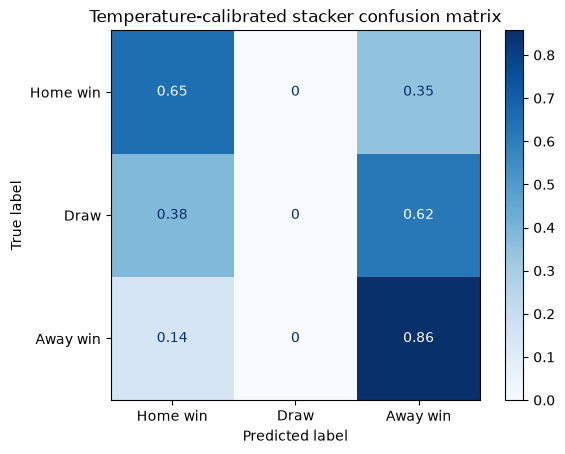

In [42]:
# ConfusionMatrixDisplay.from_predictions(
#     prediction_output["actual_result"],
#     prediction_output["threshold_predicted_result"],
#     labels=CLASS_LABELS,
#     normalize="true",
#     cmap="Blues",
# )

# plt.title("Threshold-rule confusion matrix")
# plt.show()

ConfusionMatrixDisplay.from_predictions(
    prediction_output["actual_result"],
    prediction_output["stacked_predicted_result"],
    labels=CLASS_LABELS,
    normalize="true",
    cmap="Blues",
)

plt.title("Temperature-calibrated stacker confusion matrix")
plt.show()

In [43]:
# print("Threshold-rule classification report")

# print(
#     classification_report(
#         prediction_output["actual_result"],
#         prediction_output["threshold_predicted_result"],
#         labels=CLASS_LABELS,
#     )
# )
print("Temperature-calibrated stacker classification report")

print(
    classification_report(
        prediction_output["actual_result"],
        prediction_output["stacked_predicted_result"],
        labels=CLASS_LABELS,
    )
)

Temperature-calibrated stacker classification report
              precision    recall  f1-score   support

    Home win       0.63      0.65      0.64      2879
        Draw       0.00      0.00      0.00      1821
    Away win       0.55      0.86      0.67      3006

    accuracy                           0.58      7706
   macro avg       0.39      0.50      0.44      7706
weighted avg       0.45      0.58      0.50      7706



/home/pradhan/miniconda3/envs/FIFAmodeling/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pradhan/miniconda3/envs/FIFAmodeling/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pradhan/miniconda3/envs/FIFAmodeling/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [ ]:

# # ==========================================================
# # Multi-class confusion matrix
# # ==========================================================

# labels = ["Home win", "Draw", "Away win"]

# cm = confusion_matrix(
#     prediction_output["actual_result"],
#     prediction_output["predicted_result"],
#     labels=labels,
# )

# disp = ConfusionMatrixDisplay(
#     confusion_matrix=cm,
#     display_labels=labels,
# )

# disp.plot(cmap="Blues")
# plt.title("Confusion Matrix")
# plt.show()


# # ==========================================================
# # Home-win metrics
# # ==========================================================

# home_metrics = {
#     "Log Loss": log_loss(
#         prediction_output["actual_home_win"],
#         prediction_output["prob_home_win"],
#     ),
#     "Brier Score": brier_score_loss(
#         prediction_output["actual_home_win"],
#         prediction_output["prob_home_win"],
#     ),
#     "ROC AUC": roc_auc_score(
#         prediction_output["actual_home_win"],
#         prediction_output["prob_home_win"],
#     ),
#     "Average Precision": average_precision_score(
#         prediction_output["actual_home_win"],
#         prediction_output["prob_home_win"],
#     ),
#     "Accuracy": accuracy_score(
#         prediction_output["actual_home_win"],
#         prediction_output["home_win_prediction"],
#     ),
#     "Precision": precision_score(
#         prediction_output["actual_home_win"],
#         prediction_output["home_win_prediction"],
#         zero_division=0,
#     ),
#     "Recall": recall_score(
#         prediction_output["actual_home_win"],
#         prediction_output["home_win_prediction"],
#         zero_division=0,
#     ),
#     "F1": f1_score(
#         prediction_output["actual_home_win"],
#         prediction_output["home_win_prediction"],
#         zero_division=0,
#     ),
# }

# # ==========================================================
# # Away-win metrics
# # ==========================================================

# away_metrics = {
#     "Log Loss": log_loss(
#         prediction_output["actual_away_win"],
#         prediction_output["prob_away_win"],
#     ),
#     "Brier Score": brier_score_loss(
#         prediction_output["actual_away_win"],
#         prediction_output["prob_away_win"],
#     ),
#     "ROC AUC": roc_auc_score(
#         prediction_output["actual_away_win"],
#         prediction_output["prob_away_win"],
#     ),
#     "Average Precision": average_precision_score(
#         prediction_output["actual_away_win"],
#         prediction_output["prob_away_win"],
#     ),
#     "Accuracy": accuracy_score(
#         prediction_output["actual_away_win"],
#         prediction_output["away_win_prediction"],
#     ),
#     "Precision": precision_score(
#         prediction_output["actual_away_win"],
#         prediction_output["away_win_prediction"],
#         zero_division=0,
#     ),
#     "Recall": recall_score(
#         prediction_output["actual_away_win"],
#         prediction_output["away_win_prediction"],
#         zero_division=0,
#     ),
#     "F1": f1_score(
#         prediction_output["actual_away_win"],
#         prediction_output["away_win_prediction"],
#         zero_division=0,
#     ),
# }

# print("\nHome Win Metrics")
# display(pd.DataFrame(home_metrics, index=["Value"]).T.rename(columns={"Value": "Home"}))

# print("\nAway Win Metrics")
# display(pd.DataFrame(away_metrics, index=["Value"]).T.rename(columns={"Value": "Away"}))